In [57]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

In [58]:
model_path = r"C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/churn_model.pkl"
data_path = r"C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/processed_data.pkl"
model = joblib.load(model_path)
X_train, X_test, y_train, y_test = joblib.load(data_path)
print("Model and data loaded successfully!")

Model loaded successfully


In [59]:
model_path = r"C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/churn_model.pkl"
model = joblib.load(model_path)
print("Model loaded successfully")

Model loaded successfully


In [55]:
#convert datafream
X_test_df = pd.DataFrame(
    X_test,
    columns=[f"Feature_{i}" for i in range(X_test.shape[1])]
)
X_test_df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18
0,-1.009559,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.062723,-1.183234,-0.918838,-1.029919,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,-1.328164,-0.996471
1,0.990532,-0.439916,-0.966622,-0.654012,0.351370,0.327438,1.117034,1.527734,0.244242,0.106315,0.108600,0.235518,0.016526,0.008503,-0.828207,0.829798,-1.474052,-1.313208,-0.567508
2,-1.009559,-0.439916,1.034530,1.529024,0.799294,0.327438,-0.991588,1.527734,0.244242,0.106315,0.108600,0.235518,0.016526,0.008503,1.570749,-1.205113,1.334863,-1.509300,-0.551945
3,-1.009559,-0.439916,-0.966622,-0.654012,-1.277445,0.327438,-0.991588,0.172250,-0.918838,-1.029919,1.245111,-0.925262,-1.113495,-1.121405,-0.828207,-1.205113,0.398558,0.385148,-0.973713
4,0.990532,-0.439916,-0.966622,-0.654012,1.410099,0.327438,-0.991588,-1.183234,-0.918838,-1.029919,-1.027910,1.396299,-1.113495,-1.121405,1.570749,-1.205113,-1.474052,-0.472339,0.431848


In [60]:
#Create SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(
    X_test_df,
    check_additivity=False
)

X_test shape: (1409, 19)
SHAP shape: (1409, 19)
Data shape: (1409, 19)


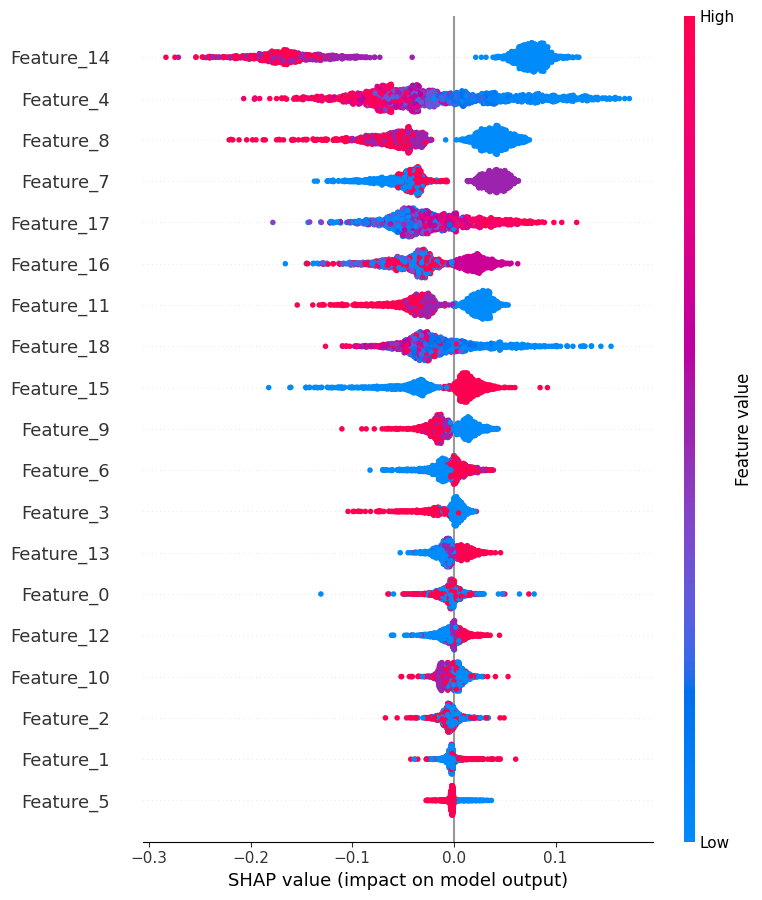

In [73]:
import shap
import pandas as pd
import joblib
import numpy as np

# Load model
model = joblib.load(
r"C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/churn_model.pkl"
)

# Load processed data
X_train, X_test, y_train, y_test = joblib.load(
r"C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/processed_data.pkl"
)

print("X_test shape:", X_test.shape)

# Convert to DataFrame
X_test_df = pd.DataFrame(
    X_test,
    columns=[f"Feature_{i}" for i in range(X_test.shape[1])]
)

# Create explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(
    X_test_df,
    check_additivity=False
)

# Handle different SHAP formats
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]   # binary classification → class 1
else:
    # if shape is (samples, features, classes)
    shap_values_class1 = shap_values[:, :, 1]

print("SHAP shape:", shap_values_class1.shape)
print("Data shape:", X_test_df.shape)

# Ensure shapes match
assert shap_values_class1.shape == X_test_df.shape, "Shape mismatch between SHAP values and data"

# SHAP Summary Plot
shap.summary_plot(
    shap_values_class1,
    X_test_df
)

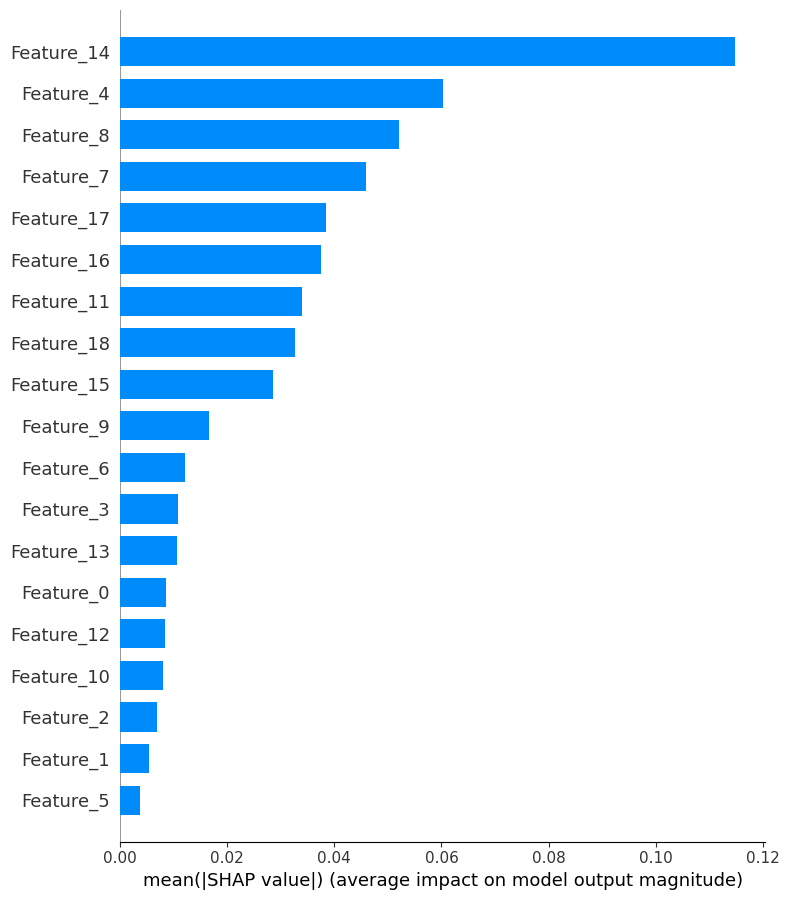

In [74]:
#Feature Importance (SHAP)
shap.summary_plot(
    shap_values_class1,
    X_test_df,
    plot_type="bar"
)

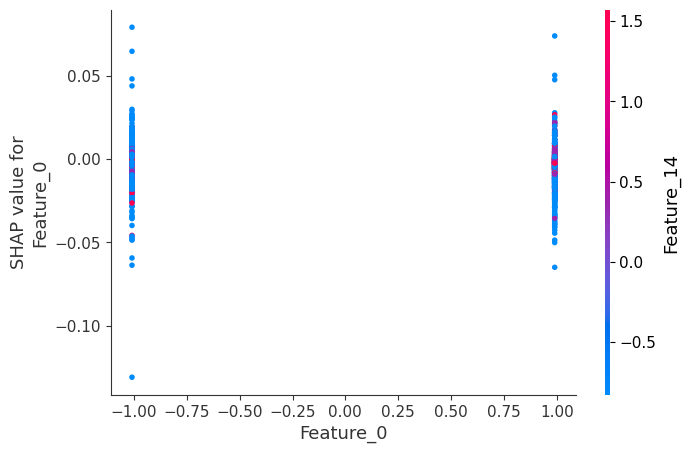

In [75]:
#Dependence Plot
shap.dependence_plot(
    0,
    shap_values_class1,
    X_test_df
)

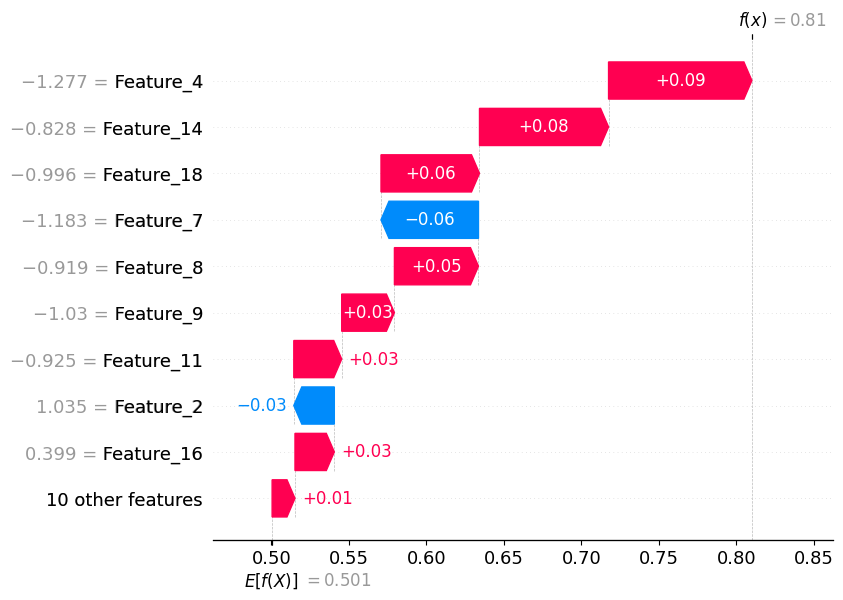

In [76]:
#Waterfall Plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_class1[0],
        base_values=explainer.expected_value[1],
        data=X_test_df.iloc[0],
        feature_names=X_test_df.columns
    )
)

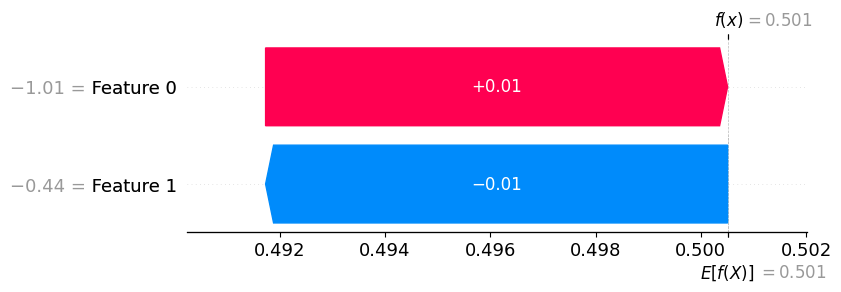

In [77]:
#Waterfall Plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer.expected_value[1],
        data=X_test[0]
    )
)

In [80]:
#Force Plot
shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[0],
    X_test_df.iloc[0]
)

In [81]:
#Top Churn Drivers Table
importance = np.abs(shap_values_class1).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X_test_df.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)
importance_df.head(10)

,Feature,Importance
14,Feature_14,0.114709
4,Feature_4,0.060267
8,Feature_8,0.052153
7,Feature_7,0.046010
17,Feature_17,0.038510
16,Feature_16,0.037507
11,Feature_11,0.033977
18,Feature_18,0.032749
15,Feature_15,0.028596
9,Feature_9,0.016645
